In [212]:
from headers import functions as fn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from headers import thermal_interpolator as ti


In [213]:
def sine(X):
    F = np.sin( X  ) 
    dFdX = (np.pi*2) * np.cos( X )
    d2FdX2 = -  (np.pi*2) *(np.pi*2) * np.sin( X )
    return F, dFdX, d2FdX2


def parabola(x):
    F = x**2
    dFdX = 2* x * 4
    d2FdX2 = np.full_like(F, 2)* 16
    return F, dFdX, d2FdX2


def nat_log(x):
    F = np.log(x)
    dFdX = 9.0 /  ( x)
    d2FdX2 = -81.0 / ( x**2)
    return F, dFdX, d2FdX2


In [214]:
num_points = 4000
SEED = 21

In [215]:
# Uniform grid
dx_eff = 1.0/(num_points-1)
xmin = 0 
xmax = 1 
x = np.linspace(xmin, xmax, num_points)


F = np.zeros_like(x)
dFdX = np.zeros_like(x)
d2FdX2 = np.zeros_like(x)
F, dFdX, d2FdX2 = sine(x*(np.pi*2))

# Normalize
scales = np.array([np.max(np.abs(F)), np.max(np.abs(dFdX)), np.max(np.abs(d2FdX2))])


np.random.seed(SEED)
n_validation = 800
X_validation = np.sort( np.random.rand(n_validation))
F_validation,dFdX_validation,d2FdX2_validation = sine(X_validation*(np.pi*2))
Fn_validation = F_validation

validation_data = np.column_stack([X_validation.ravel(), F_validation.ravel(), Fn_validation.ravel(), dFdX_validation.ravel(), d2FdX2_validation.ravel()] )



Fn = F #(no noise)
training_data = np.column_stack([x.ravel(), F.ravel(), Fn.ravel(), dFdX.ravel(), d2FdX2.ravel()] )

y_implicit, dFdX_implicit, d2FdX2_implicit, _, _, _ = ti.derivatives_1D_matrix(validation_data, noise_token=0, training_data = training_data, scale = 1.0)


print(f"Implicit Scheme MSE phi' : {(ti.L2(dFdX_implicit[:], dFdX_validation[:]))**2}")
print(f"Implicit Scheme MSE phi'': {(ti.L2(d2FdX2_implicit[:], d2FdX2_validation[:]))**2}")


y_explicit, dFdX_explicit, d2FdX2_explicit, _, _ = ti.derivatives_1D_explicit(validation_data, noise_token=0, training_data = training_data, scale = 1.0)

print(f"Explicit Scheme MSE phi' : {(ti.L2(dFdX_explicit[:], dFdX_validation[:]))**2}")
print(f"Explicit Scheme MSE phi'': {(ti.L2(d2FdX2_explicit[:], d2FdX2_validation[:]))**2}")




running implicit


/home/abhishek/Desktop/Workstation/ML/ICLR2026/headers/thermal_interpolator.py:966: RuntimeWarning: divide by zero encountered in divide
/home/abhishek/Desktop/Workstation/ML/ICLR2026/headers/thermal_interpolator.py:966: RuntimeWarning: invalid value encountered in divide


Selected theta is 1.8560246709669817e-08, with test rmse 2.1756139077254371e-10, index is 7
Complete!
Implicit Scheme MSE phi' : 6.6003880092503006e-12
Implicit Scheme MSE phi'': 0.00022137482396356576

running explicit


/home/abhishek/Desktop/Workstation/ML/ICLR2026/headers/thermal_interpolator.py:555: RuntimeWarning: divide by zero encountered in divide
  c = (Y_train - Y_train_predict) / (theta_train)
/home/abhishek/Desktop/Workstation/ML/ICLR2026/headers/thermal_interpolator.py:555: RuntimeWarning: invalid value encountered in divide
  c = (Y_train - Y_train_predict) / (theta_train)


Selected theta is 1.8560246709669817e-08, with test rmse 2.1756139077254371e-10, index is 7
-------------------------------------
Complete!
Explicit Scheme MSE phi' : 3.1239484804566037e-12
Explicit Scheme MSE phi'': 6.496915125984286e-05


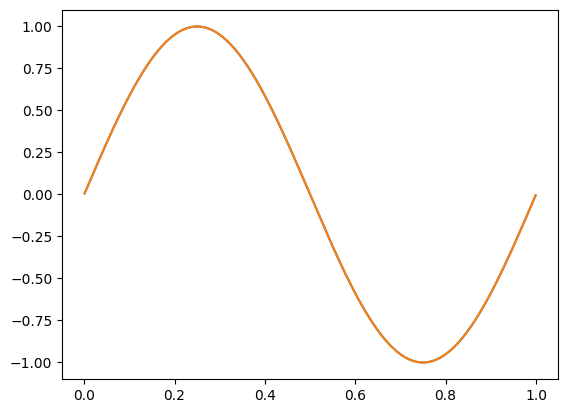

In [216]:
plt.plot(X_validation,F_validation)
# plt.plot(X_validation,y_implicit)
plt.plot(X_validation,y_explicit)



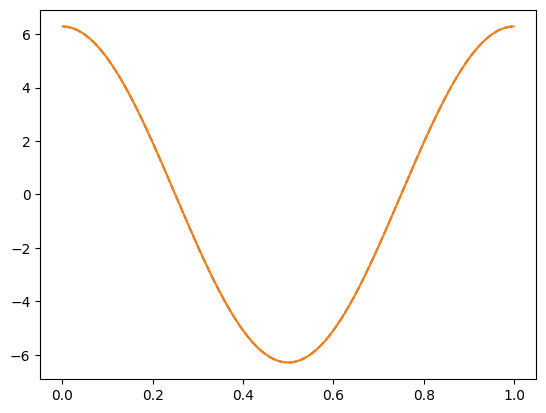

In [217]:
# plt.plot(X_validation,dFdX_implicit,'.-')
plt.plot(X_validation,dFdX_explicit,'--')
plt.plot(X_validation,dFdX_validation)

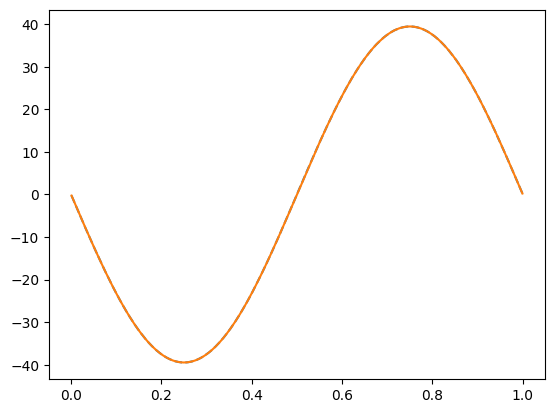

In [218]:
# plt.plot(X_validation,d2FdX2_implicit,'.-')
plt.plot(X_validation,d2FdX2_explicit,'--')
plt.plot(X_validation,d2FdX2_validation)

In [219]:
# Uniform grid
dx_eff = 1.0/(num_points-1)
xmin = 0 
xmax = 1 
x = np.linspace(xmin, xmax, num_points)


F = np.zeros_like(x)
dFdX = np.zeros_like(x)
d2FdX2 = np.zeros_like(x)
F, dFdX, d2FdX2 = parabola(4*x-2)

# Normalize
scales = np.array([np.max(np.abs(F)), np.max(np.abs(dFdX)), np.max(np.abs(d2FdX2))])

# F = fn.Normalize(F,scales[0])
# dFdX = fn.Normalize(dFdX,scales[0])
# d2FdX2 = fn.Normalize(d2FdX2,scales[0])


np.random.seed(SEED)
n_validation = 800
X_validation = np.sort( np.random.rand(n_validation))
F_validation,dFdX_validation,d2FdX2_validation = parabola(4*X_validation-2)

# F_validation = fn.Normalize(F_validation,scales[0])
# dFdX_validation = fn.Normalize(dFdX_validation,scales[0])
# d2FdX2_validation = fn.Normalize(d2FdX2_validation,scales[0])

Fn_validation = F_validation
validation_data = np.column_stack([X_validation.ravel(), F_validation.ravel(), Fn_validation.ravel(), dFdX_validation.ravel(), d2FdX2_validation.ravel()] )



Fn = F.copy() #(no noise)
training_data = np.column_stack([x.ravel(), F.ravel(), Fn.ravel(), dFdX.ravel(), d2FdX2.ravel()] )

y_implicit, dFdX_implicit, d2FdX2_implicit, _, _, _ = ti.derivatives_1D_matrix(validation_data, noise_token=0, training_data = training_data, scale = 1.0)


print(f"Implicit Scheme MSE phi' : {(ti.L2(dFdX_implicit[:], dFdX_validation[:]))**2}")
print(f"Implicit Scheme MSE phi'': {(ti.L2(d2FdX2_implicit[:], d2FdX2_validation[:]))**2}")


y_explicit, dFdX_explicit, d2FdX2_explicit, _, _ = ti.derivatives_1D_explicit(validation_data, noise_token=0, training_data = training_data, scale = 1.0)

print(f"Explicit Scheme MSE phi' : {(ti.L2(dFdX_explicit[:], dFdX_validation[:]))**2}")
print(f"Explicit Scheme MSE phi'': {(ti.L2(d2FdX2_explicit[:], d2FdX2_validation[:]))**2}")




running implicit


/home/abhishek/Desktop/Workstation/ML/ICLR2026/headers/thermal_interpolator.py:966: RuntimeWarning: invalid value encountered in divide
/home/abhishek/Desktop/Workstation/ML/ICLR2026/headers/thermal_interpolator.py:966: RuntimeWarning: divide by zero encountered in divide


Selected theta is 1.8560246709669817e-08, with test rmse 5.5177464535008155e-11, index is 7
Complete!
Implicit Scheme MSE phi' : 8.139651745841354e-13
Implicit Scheme MSE phi'': 0.00032731009575204473

running explicit


/home/abhishek/Desktop/Workstation/ML/ICLR2026/headers/thermal_interpolator.py:555: RuntimeWarning: invalid value encountered in divide
  c = (Y_train - Y_train_predict) / (theta_train)
/home/abhishek/Desktop/Workstation/ML/ICLR2026/headers/thermal_interpolator.py:555: RuntimeWarning: divide by zero encountered in divide
  c = (Y_train - Y_train_predict) / (theta_train)


Selected theta is 1.8560246709669817e-08, with test rmse 5.5177464535008155e-11, index is 7
-------------------------------------
Complete!
Explicit Scheme MSE phi' : 3.243823365293531e-19
Explicit Scheme MSE phi'': 3.075160773010397e-14


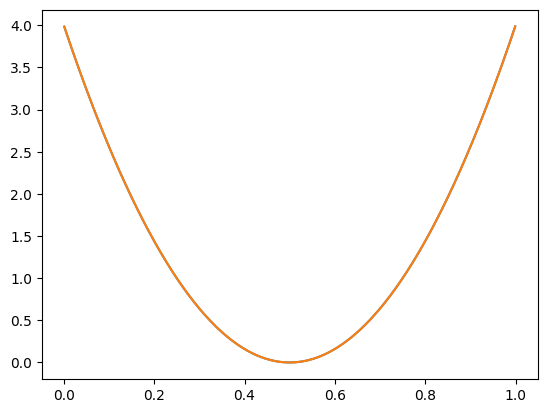

In [220]:
plt.plot(X_validation,F_validation)
# plt.plot(X_validation,y_implicit)
plt.plot(X_validation,y_explicit)


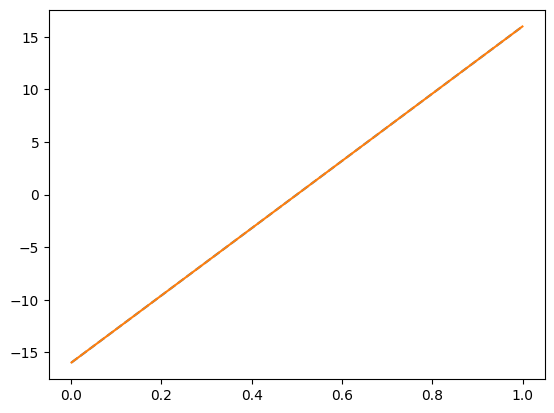

In [221]:
# plt.plot(X_validation,dFdX_implicit,'.-')
plt.plot(X_validation,dFdX_explicit,'--')
plt.plot(X_validation,dFdX_validation)

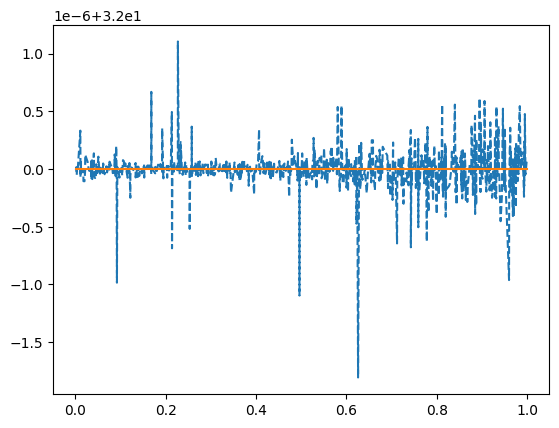

In [222]:
# plt.plot(X_validation,d2FdX2_implicit,'.-')
plt.plot(X_validation,d2FdX2_explicit,'--')
plt.plot(X_validation,d2FdX2_validation)

In [223]:
# Uniform grid
dx_eff = 1.0/(num_points-1)
xmin = 0 
xmax = 1 
x = np.linspace(xmin, xmax, num_points)


F = np.zeros_like(x)
dFdX = np.zeros_like(x)
d2FdX2 = np.zeros_like(x)
F, dFdX, d2FdX2 = nat_log(9*x + 1)

# Normalize
scales = np.array([np.max(np.abs(F)), np.max(np.abs(dFdX)), np.max(np.abs(d2FdX2))])


np.random.seed(SEED)
n_validation = 800
X_validation = np.sort( np.random.rand(n_validation))
F_validation,dFdX_validation,d2FdX2_validation = nat_log(9*X_validation + 1)



Fn_validation = F_validation
validation_data = np.column_stack([X_validation.ravel(), F_validation.ravel(), Fn_validation.ravel(), dFdX_validation.ravel(), d2FdX2_validation.ravel()] )



Fn = F #(no noise)
training_data = np.column_stack([x.ravel(), F.ravel(), Fn.ravel(), dFdX.ravel(), d2FdX2.ravel()] )

y_implicit, dFdX_implicit, d2FdX2_implicit, _, _, _ = ti.derivatives_1D_matrix(validation_data, noise_token=0, training_data = training_data, scale = 1.0)


print(f"Implicit Scheme MSE phi' : {(ti.L2(dFdX_implicit[:], dFdX_validation[:]))**2}")
print(f"Implicit Scheme MSE phi'': {(ti.L2(d2FdX2_implicit[:], d2FdX2_validation[:]))**2}")


y_explicit, dFdX_explicit, d2FdX2_explicit, _, _ = ti.derivatives_1D_explicit(validation_data, noise_token=0, training_data = training_data, scale = 1.0)

print(f"Explicit Scheme MSE phi' : {(ti.L2(dFdX_explicit[:], dFdX_validation[:]))**2}")
print(f"Explicit Scheme MSE phi'': {(ti.L2(d2FdX2_explicit[:], d2FdX2_validation[:]))**2}")




running implicit


/home/abhishek/Desktop/Workstation/ML/ICLR2026/headers/thermal_interpolator.py:966: RuntimeWarning: invalid value encountered in divide
/home/abhishek/Desktop/Workstation/ML/ICLR2026/headers/thermal_interpolator.py:966: RuntimeWarning: divide by zero encountered in divide


Selected theta is 1.8560246709669817e-08, with test rmse 1.7129929028623945e-10, index is 7
Complete!
Implicit Scheme MSE phi' : 8.921760176040413e-12
Implicit Scheme MSE phi'': 0.00025263804528406433

running explicit


/home/abhishek/Desktop/Workstation/ML/ICLR2026/headers/thermal_interpolator.py:555: RuntimeWarning: invalid value encountered in divide
  c = (Y_train - Y_train_predict) / (theta_train)
/home/abhishek/Desktop/Workstation/ML/ICLR2026/headers/thermal_interpolator.py:555: RuntimeWarning: divide by zero encountered in divide
  c = (Y_train - Y_train_predict) / (theta_train)


Selected theta is 1.8560246709669817e-08, with test rmse 1.7129929028623945e-10, index is 7
-------------------------------------
Complete!
Explicit Scheme MSE phi' : 3.879500136013033e-12
Explicit Scheme MSE phi'': 0.0001343020206239335


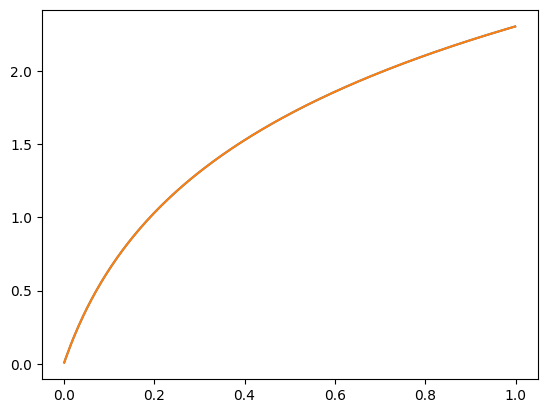

In [224]:
plt.plot(X_validation,F_validation)
# plt.plot(X_validation,y_implicit)
plt.plot(X_validation,y_explicit)


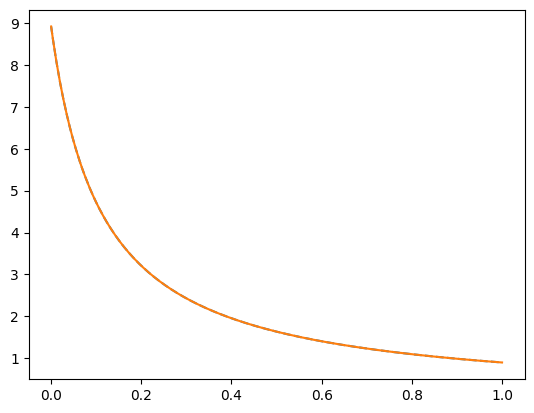

In [225]:
# plt.plot(X_validation,dFdX_implicit,'.-')
plt.plot(X_validation,dFdX_explicit,'--')
plt.plot(X_validation,dFdX_validation)

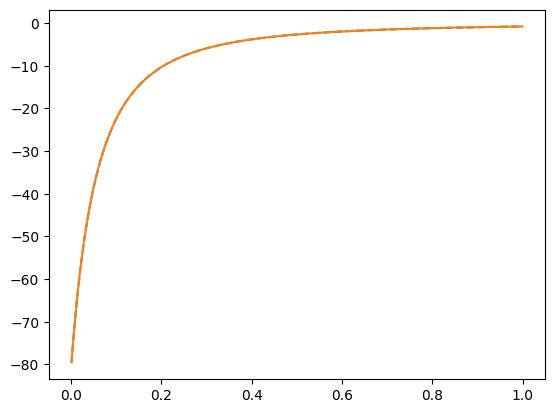

In [226]:
# plt.plot(X_validation,d2FdX2_implicit,'.-')
plt.plot(X_validation,d2FdX2_explicit,'--')
plt.plot(X_validation,d2FdX2_validation)